In [5]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import NUTS, MCMC
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict
import warnings

class BayesianPPCA:
    """
    Bayesian Probabilistic Principal Component Analysis using NUTS sampling.
    
    Based on Tipping & Bishop (1999) "Probabilistic principal component analysis"
    
    Model:
    t = W @ x + μ + ε
    where:
    - q: n-dimensional observation
    - qhat ~ N(0, I): q-dimensional latent variable  
    - V: n*r loading matrix
    - qbar: n-dimensional mean
    - ε ~ N(0, sig^2I): isotropic Gaussian noise
    
    This gives: t ~ N(qbar, V @ V^T + sig^2I)
    """
    
    def __init__(self, latent_dim: int, obs_dim: int, device: str = "cpu"):
        self.latent_dim = latent_dim
        self.obs_dim = obs_dim
        self.device = device
        self.mcmc = None
        self.samples = None
        
    def model(self, data: torch.Tensor) -> None:
        """
        Pyro model for PPCA.
        
        Args:
            data: Tensor of shape (n_samples, obs_dim)
        """
        n_samples, obs_dim = data.shape
        
        # Priors
        # Loading matrix W with appropriate scale
        V = pyro.sample("V", dist.Normal(
            torch.zeros(obs_dim, self.latent_dim, device=self.device),
            torch.ones(obs_dim, self.latent_dim, device=self.device)
        ).to_event(2))
        
        # Mean parameter
        qbar = pyro.sample("qbar", dist.Normal(
            torch.zeros(obs_dim, device=self.device),
            torch.ones(obs_dim, device=self.device) * 2.0
        ).to_event(1))
        
        # Noise variance (use log-normal to ensure positivity)
        log_sigma2 = pyro.sample("log_sigma2", dist.Normal(
            torch.tensor(0.0, device=self.device),
            torch.tensor(1.0, device=self.device)
        ))
        sigma2 = torch.exp(log_sigma2)
        
        # Latent variables for each observation
        with pyro.plate("data", n_samples):
            qhat = pyro.sample("qhat", dist.Normal(
                torch.zeros(self.latent_dim, device=self.device),
                torch.ones(self.latent_dim, device=self.device)
            ).to_event(1))
            
            # Observation model: t = W @ x + μ + ε
            mean = torch.matmul(qhat, V.T) + qbar
            
            # Likelihood with isotropic Gaussian noise
            pyro.sample("obs", dist.Normal(
                mean,
                torch.sqrt(sigma2) * torch.ones_like(mean)
            ).to_event(1), obs=data)
    
    def fit(self, 
            data: torch.Tensor, 
            num_samples: int = 1000,
            warmup_steps: int = 500,
            num_chains: int = 1,
            step_size: float = 0.01) -> None:
        """
        Fit the PPCA model using NUTS sampling.
        
        Args:
            data: Training data of shape (n_samples, obs_dim)
            num_samples: Number of MCMC samples
            warmup_steps: Number of warmup steps
            num_chains: Number of MCMC chains
            step_size: Initial step size for NUTS
        """
        data = data.to(self.device)
        
        # Set up NUTS sampler
        nuts_kernel = NUTS(self.model, step_size=step_size, adapt_step_size=True)
        
        # Run MCMC
        self.mcmc = MCMC(
            nuts_kernel,
            num_samples=num_samples,
            warmup_steps=warmup_steps,
            num_chains=num_chains
        )
        
        print("Running NUTS sampling...")
        self.mcmc.run(data)
        
        # Get samples
        self.samples = self.mcmc.get_samples()
        
        print(f"Sampling completed. Collected {num_samples} samples.")
        
    def get_posterior_mean(self) -> Dict[str, torch.Tensor]:
        """Get posterior means of parameters."""
        if self.samples is None:
            raise ValueError("Model must be fitted first.")
            
        posterior_means = {}
        for param_name, samples in self.samples.items():
            if param_name != "x":  # x is latent variables, not model parameters
                posterior_means[param_name] = samples.mean(dim=0)
                
        return posterior_means
    
    def get_principal_components(self) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Extract principal components from posterior samples.
        
        Returns:
            Tuple of (eigenvalues, eigenvectors) averaged over posterior samples
        """
        if self.samples is None:
            raise ValueError("Model must be fitted first.")
            
        W_samples = self.samples["V"]  # Shape: (n_samples, obs_dim, latent_dim)
        sigma2_samples = torch.exp(self.samples["log_sigma2"])  # Shape: (n_samples,)
        
        eigenvalues_list = []
        eigenvectors_list = []
        
        for i in range(W_samples.shape[0]):
            W = W_samples[i]  # (obs_dim, latent_dim)
            sigma2 = sigma2_samples[i]
            
            # Compute covariance matrix C = W @ W^T + σ²I
            C = W @ W.T + sigma2 * torch.eye(self.obs_dim, device=self.device)
            
            # Eigendecomposition
            eigenvals, eigenvecs = torch.linalg.eigh(C)
            
            # Sort in descending order
            idx = torch.argsort(eigenvals, descending=True)
            eigenvals = eigenvals[idx]
            eigenvecs = eigenvecs[:, idx]
            
            eigenvalues_list.append(eigenvals)
            eigenvectors_list.append(eigenvecs)
        
        # Average over samples
        mean_eigenvalues = torch.stack(eigenvalues_list).mean(dim=0)
        mean_eigenvectors = torch.stack(eigenvectors_list).mean(dim=0)
        
        return mean_eigenvalues, mean_eigenvectors
    
    def transform(self, data: torch.Tensor) -> torch.Tensor:
        """
        Project data into latent space using posterior mean parameters.
        
        Args:
            data: Data to transform, shape (n_samples, obs_dim)
            
        Returns:
            Latent representations, shape (n_samples, latent_dim)
        """
        if self.samples is None:
            raise ValueError("Model must be fitted first.")
            
        posterior_means = self.get_posterior_mean()
        W_mean = posterior_means["V"]  # (obs_dim, latent_dim)
        mu_mean = posterior_means["qbar"]  # (obs_dim,)
        sigma2_mean = torch.exp(posterior_means["log_sigma2"])
        
        # Center the data
        centered_data = data - mu_mean
        
        # Compute M = W^T @ W + σ²I
        M = W_mean.T @ W_mean + sigma2_mean * torch.eye(self.latent_dim, device=self.device)
        
        # Project: x = M^(-1) @ W^T @ (t - μ)
        x = torch.linalg.solve(M, W_mean.T @ centered_data.T).T
        
        return x
    
    def reconstruct(self, latent_data: torch.Tensor) -> torch.Tensor:
        """
        Reconstruct observations from latent representations.
        
        Args:
            latent_data: Latent representations, shape (n_samples, latent_dim)
            
        Returns:
            Reconstructed observations, shape (n_samples, obs_dim)
        """
        if self.samples is None:
            raise ValueError("Model must be fitted first.")
            
        posterior_means = self.get_posterior_mean()
        W_mean = posterior_means["V"]  # (obs_dim, latent_dim)
        mu_mean = posterior_means["qbar"]  # (obs_dim,)
        
        # Reconstruct: t = W @ x + μ
        reconstructed = latent_data @ W_mean.T + mu_mean
        
        return reconstructed
    
def generate_synthetic_data(n_samples: int = 200, 
                          obs_dim: int = 10, 
                          latent_dim: int = 3,
                          noise_level: float = 0.1,
                          random_seed: int = 42) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Generate synthetic data for testing PPCA."""
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    
    # True parameters
    W_true = torch.randn(obs_dim, latent_dim) * 0.5
    mu_true = torch.randn(obs_dim) * 0.2
    
    # Generate latent variables
    x_true = torch.randn(n_samples, latent_dim)
    
    # Generate observations
    noise = torch.randn(n_samples, obs_dim) * noise_level
    data = x_true @ W_true.T + mu_true + noise
    
    return data, W_true, x_true



Using device: cpu
Generating synthetic data...
Data shape: torch.Size([200, 8])
True W shape: torch.Size([8, 2])

Fitting Bayesian PPCA...
Running NUTS sampling...


Sample: 100%|██████████| 1200/1200 [00:42, 28.07it/s, step size=1.29e-01, acc. prob=0.882]


Sampling completed. Collected 800 samples.

Extracting results...
Posterior mean V shape: torch.Size([8, 2])
Posterior mean qbar shape: torch.Size([8])
Posterior mean σ²: 0.0393
Inferred latent variables shape: torch.Size([200, 2])
Reconstruction error (MSE): 0.029095
Principal eigenvalues: tensor([3.5785, 1.7448, 0.0394, 0.0394])


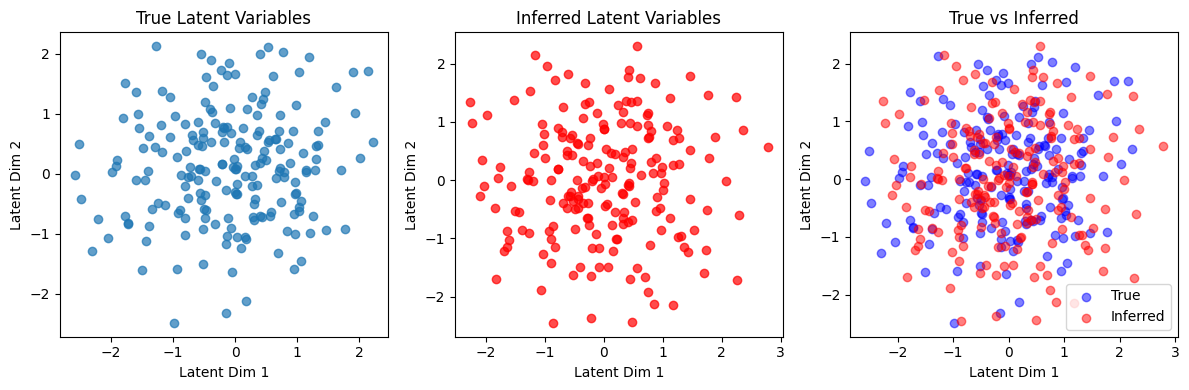


Bayesian PPCA analysis completed!


In [6]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Generate synthetic data
print("Generating synthetic data...")
n_samples, obs_dim, latent_dim = 200, 8, 2
data, W_true, x_true = generate_synthetic_data(
    n_samples=n_samples, 
    obs_dim=obs_dim, 
    latent_dim=latent_dim,
    noise_level=0.2
)

print(f"Data shape: {data.shape}")
print(f"True W shape: {W_true.shape}")

# Fit Bayesian PPCA
print("\nFitting Bayesian PPCA...")
ppca = BayesianPPCA(latent_dim=latent_dim, obs_dim=obs_dim, device=device)

ppca.fit(
    data=data.to(device),
    num_samples=800,
    warmup_steps=400,
    num_chains=1,
    step_size=0.005
)

# Get results
print("\nExtracting results...")
posterior_means = ppca.get_posterior_mean()

print(f"Posterior mean V shape: {posterior_means['V'].shape}")
print(f"Posterior mean qbar shape: {posterior_means['qbar'].shape}")
print(f"Posterior mean σ²: {torch.exp(posterior_means['log_sigma2']):.4f}")

# Transform data to latent space
x_inferred = ppca.transform(data.to(device))
print(f"Inferred latent variables shape: {x_inferred.shape}")

# Reconstruct data
data_reconstructed = ppca.reconstruct(x_inferred)
reconstruction_error = torch.mean((data.to(device) - data_reconstructed) ** 2)
print(f"Reconstruction error (MSE): {reconstruction_error:.6f}")

# Get principal components
eigenvalues, eigenvectors = ppca.get_principal_components()
print(f"Principal eigenvalues: {eigenvalues[:latent_dim+2]}")

# Visualization (if 2D latent space)
if latent_dim == 2:
    plt.figure(figsize=(12, 4))
    
    # Plot original latent variables
    plt.subplot(1, 3, 1)
    plt.scatter(x_true[:, 0], x_true[:, 1], alpha=0.7)
    plt.title("True Latent Variables")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    
    # Plot inferred latent variables
    plt.subplot(1, 3, 2)
    plt.scatter(x_inferred[:, 0].cpu(), x_inferred[:, 1].cpu(), alpha=0.7, color='red')
    plt.title("Inferred Latent Variables")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    
    # Plot comparison
    plt.subplot(1, 3, 3)
    plt.scatter(x_true[:, 0], x_true[:, 1], alpha=0.5, label='True', color='blue')
    plt.scatter(x_inferred[:, 0].cpu(), x_inferred[:, 1].cpu(), alpha=0.5, label='Inferred', color='red')
    plt.title("True vs Inferred")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

print("\nBayesian PPCA analysis completed!")